# Gravity as First Implementation Output — Strong-Field Orbital Test

This notebook advances the gravity branch in the right regime.

The working hypothesis is not that gravity is a primitive fourth force, but that it is the **first emergent implementation output** of the triadic runtime. That means the correct external test is not necessarily weak lensing first. It is any regime where a small geometric correction accumulates coherently.

The cleanest first target is apsidal / perihelion precession in bound orbits.

The aim here is:

1. write a generic emergent-output potential,
2. derive the orbital correction,
3. identify the sign constraint,
4. show why perihelion precession is the right target regime.


## 1. Generic first-implementation potential

Take the weak-field emergent potential in the minimal form

$$
\Phi(r)= -\frac{\mu}{r} + \frac{A}{r^2},
$$

where:

- $\mu = GM$ is the Newtonian specific gravitational parameter,
- $A$ is the first higher-order implementation correction,
- $A/r^2$ is not assumed to be the full theory, only the first clean correction term to test.

The corresponding central force is

$$
F(r) = -\frac{d\Phi}{dr}
      = -\frac{\mu}{r^2} + \frac{2A}{r^3}.
$$

The sign of $A$ matters:

- $A>0$ gives an effectively more repulsive short-range correction,
- $A<0$ gives an effectively more attractive short-range correction.


## 2. Binet equation and precession law

Using the Binet variable

$$
u(\varphi)=\frac{1}{r(\varphi)},
$$

and the specific angular momentum

$$
h = r^2 \dot{\varphi},
$$

the Binet equation is

$$
u'' + u = -\frac{F(1/u)}{h^2 u^2}.
$$

Substituting

$$
F(r)= -\frac{\mu}{r^2} + \frac{2A}{r^3}
$$

gives

$$
u'' + u = \frac{\mu}{h^2} - \frac{2A}{h^2}u,
$$

hence

$$
u'' + \omega_r^2 u = \frac{\mu}{h^2},
\qquad
\omega_r^2 = 1 + \frac{2A}{h^2}.
$$

So the radial oscillation frequency in angle-space is shifted from $1$ to $\omega_r$.

The apsidal angle is

$$
\Delta\varphi_{\text{apsis}} = \frac{2\pi}{\omega_r}.
$$

Therefore the perihelion shift per orbit is

$$
\boxed{
\Delta\varpi
=
2\pi\left(\frac{1}{\sqrt{1+2A/h^2}}-1\right).
}
$$

For small correction $|A| \ll h^2$,

$$
\boxed{
\Delta\varpi \approx -\,2\pi \frac{A}{h^2}.
}
$$

Since for a Kepler orbit

$$
h^2 = \mu a(1-e^2),
$$

we get

$$
\boxed{
\Delta\varpi \approx -\,\frac{2\pi A}{\mu\,a(1-e^2)}.
}
$$

This immediately shows why compact orbits are the correct regime: the signal scales like

$$
\frac{1}{a(1-e^2)}.
$$


## 3. Sign constraint

If the observed correction is **prograde**, then we need

$$
\Delta\varpi > 0.
$$

But for the first-order approximation

$$
\Delta\varpi \approx -2\pi A/h^2,
$$

that means

$$
\boxed{
A < 0
}
$$

for prograde precession.

So the sign of the emergent-output correction is not optional.

If the first implementation output produces an effective $+A/r^2$ with $A>0$, then it predicts a retrograde correction.

Therefore:

$$
\boxed{
\text{any gravity-as-output model must either produce } A<0
\text{ at leading order,}
}
$$

or else the true correction must enter through a more metric-like route than this bare potential proxy.


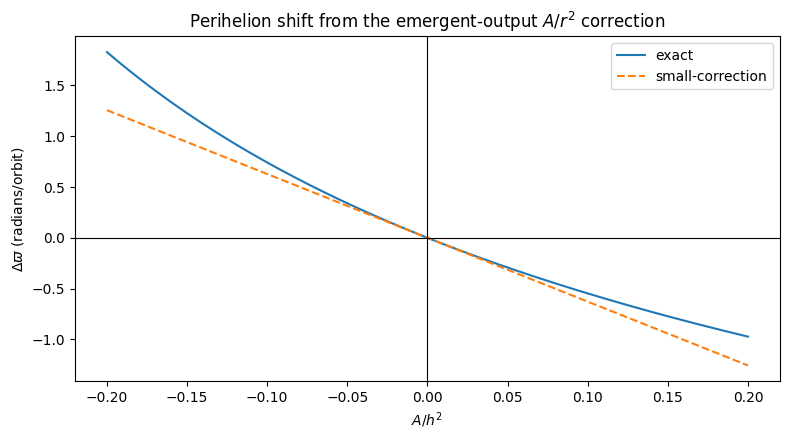

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def delta_varpi_exact(A_over_h2):
    x = 1 + 2 * A_over_h2
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = 2*np.pi*(1/np.sqrt(x[mask]) - 1)
    return out

def delta_varpi_small(A_over_h2):
    x = np.asarray(A_over_h2, dtype=float)
    return -2*np.pi*x

Aoh2 = np.linspace(-0.2, 0.2, 401)
exact = delta_varpi_exact(Aoh2)
approx = delta_varpi_small(Aoh2)

plt.figure(figsize=(8,4.5))
plt.plot(Aoh2, exact, label="exact")
plt.plot(Aoh2, approx, "--", label="small-correction")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel(r"$A/h^2$")
plt.ylabel(r"$\Delta\varpi$ (radians/orbit)")
plt.title("Perihelion shift from the emergent-output $A/r^2$ correction")
plt.legend()
plt.tight_layout()
plt.show()


The plot above makes the sign issue explicit:

- $A<0$ gives prograde precession,
- $A>0$ gives retrograde precession.

That is already a valuable constraint on any deeper gravity-as-output theory.


## 4. Why the solar-limb regime is the wrong first target

If the correction is genuinely higher-order, then in weak, broad fields it is suppressed by the orbital or impact scale.

So a correction that is structurally real can still be observationally invisible in solar-limb lensing while becoming relevant in compact or high-eccentricity orbital motion.

The correct lesson is:

$$
\boxed{
\text{the first discriminating regime for the gravity branch is strong-field orbital accumulation, not weak-field wide-angle bending.}
}
$$

That is exactly why perihelion precession and compact objects are the right first targets.


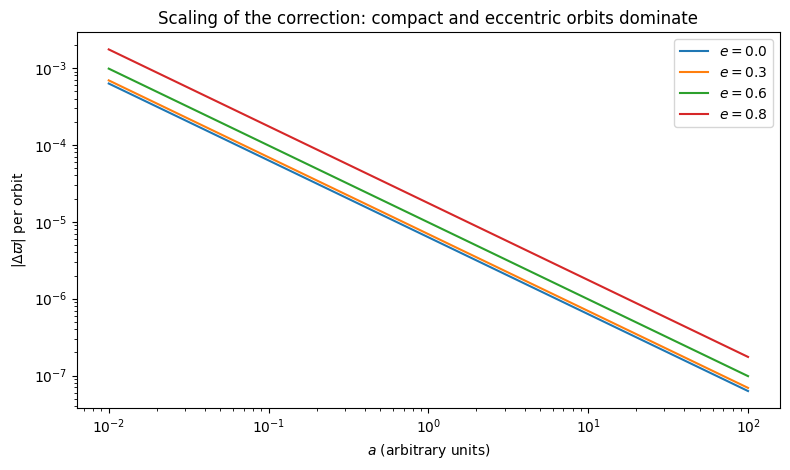

In [2]:

mu = 1.0   # dimensionless for scaling
A = -1e-6  # choose negative for prograde example

a_vals = np.logspace(-2, 2, 400)
e_list = [0.0, 0.3, 0.6, 0.8]

plt.figure(figsize=(8,4.8))
for e in e_list:
    dvarpi = -2*np.pi*A/(mu*a_vals*(1-e**2))
    plt.loglog(a_vals, np.abs(dvarpi), label=fr"$e={e}$")
plt.xlabel(r"$a$ (arbitrary units)")
plt.ylabel(r"$|\Delta\varpi|$ per orbit")
plt.title("Scaling of the correction: compact and eccentric orbits dominate")
plt.legend()
plt.tight_layout()
plt.show()


The scaling law

$$
\boxed{
\Delta\varpi \propto \frac{1}{a(1-e^2)}
}
$$

is the central reason the gravity branch should be pushed to:

- compact systems,
- eccentric systems,
- dense-source environments,
- or other regimes where the correction accumulates coherently.


## 5. Gravity as first implementation output

This orbital derivation fits the larger architecture cleanly.

The runtime stack is:

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
\rho_\Gamma
\to
v_{\mathrm{eff}}
\to
\kappa
\to
\Phi(r)
\to
\Delta\varpi,\ \text{lensing},\ \text{clock shift}.
}
$$

So gravity is not the runtime itself.
It is the first measurable output of the runtime after the retention geometry has already formed.

That is why the question "what breaks without gravity?" was so useful.

Without this layer:

- persistent objects have no shared exterior consequence,
- clocks have no common geometric bias,
- bound paths have no universal curvature rule,
- and the runtime never becomes a shared world.


## 6. What this notebook actually proves

This notebook does **not** prove the whole gravity theory.

It does prove something narrower and useful:

1. if the first emergent-output correction is represented by an $A/r^2$ term,
2. then the perihelion shift is

$$
\boxed{
\Delta\varpi
=
2\pi\left(\frac{1}{\sqrt{1+2A/h^2}}-1\right),
}
$$

3. and the sign of the precession fixes the sign of $A$.

So the gravity-as-output branch now has a **sign constraint** and a **target regime**.

That is a real advance.


## 7. Next exact move

The next clean continuation is:

1. tie $A$ back to a concrete maintenance / cut-density source,
2. determine whether the emergent-output model predicts $A<0$ or $A>0$,
3. and test the result in the compact/eccentric regime rather than weak solar-limb bending first.
